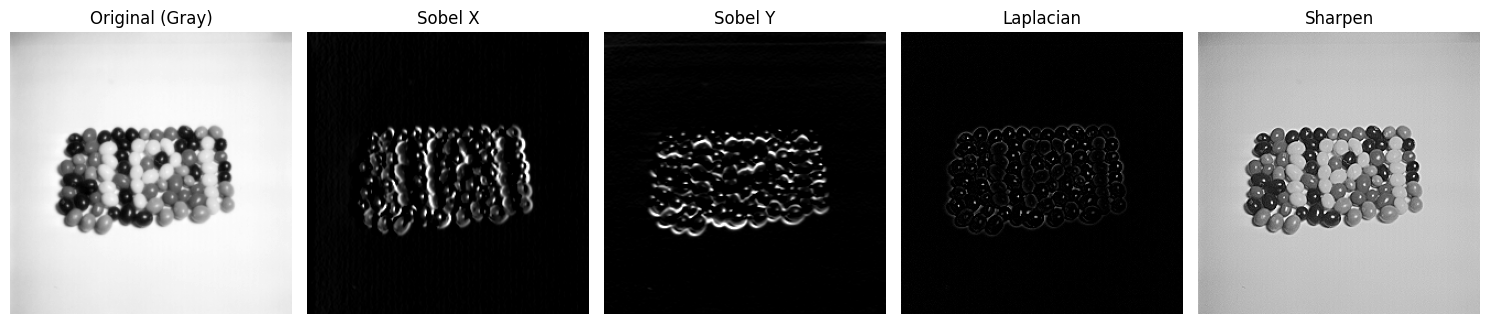

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('image/4.1.07.tiff') 
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Define kernels
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

laplacian = np.array([[ 0, -1,  0],
                      [-1,  4, -1],
                      [ 0, -1,  0]])

sharpen = np.array([[ 0, -1,  0],
                    [-1,  5, -1],
                    [ 0, -1,  0]])

# Apply filters
filtered_sobel_x = cv2.filter2D(gray, -1, sobel_x)
filtered_sobel_y = cv2.filter2D(gray, -1, sobel_y)
filtered_laplacian = cv2.filter2D(gray, -1, laplacian)
filtered_sharpen = cv2.filter2D(gray, -1, sharpen)

# Plot original and filtered images
titles = ['Original (Gray)', 'Sobel X', 'Sobel Y', 'Laplacian', 'Sharpen']
images = [gray, filtered_sobel_x, filtered_sobel_y, filtered_laplacian, filtered_sharpen]

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Simple CNN (1 conv layer + 1 fc layer)
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(16 * 14 * 14, 10) 

    def forward(self, x):
        x = self.pool(torch.relu(self.conv(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)

# Model, optimizer, loss
model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training loop
for epoch in range(3):  
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}: Accuracy = {100*correct/total:.2f}%")



Epoch 1: Accuracy = 84.60%
Epoch 2: Accuracy = 89.00%
Epoch 3: Accuracy = 90.08%


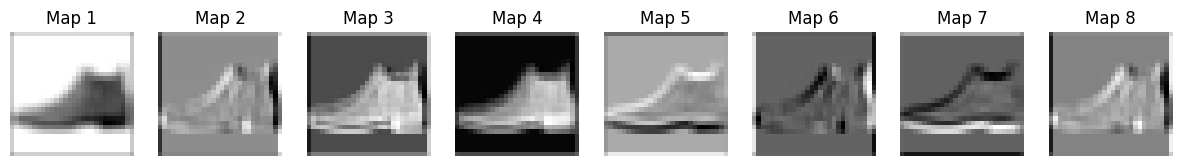

In [ ]:
# Get one test image
dataiter = iter(testloader)
images, labels = next(dataiter)
img = images[0].unsqueeze(0).to(device)  

# Forward pass through the first convolutional layer
with torch.no_grad():
    if 'model' in globals():
        conv = model.conv_layer[0]
    else:
        raise RuntimeError("No model found in notebook.")

    feature_maps = conv(img)

# Convert feature maps to NumPy array
feature_maps = feature_maps.squeeze(0).cpu().numpy()

# Plot the first few feature maps
num_features = min(8, feature_maps.shape[0]) 
fig, axes = plt.subplots(1, num_features, figsize=(15, 5))

for i in range(num_features):
    axes[i].imshow(feature_maps[i], cmap="gray")
    axes[i].axis("off")
    axes[i].set_title("Map {}".format(i+1))

plt.show()


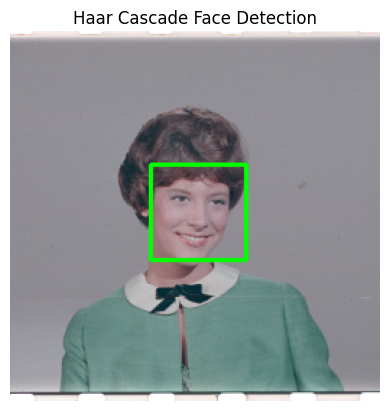

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("image/4.1.03.tiff")  
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)   

# Load Haar Cascade for frontal face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

if len(faces) > 0:
    for (x, y, w, h) in faces:
        cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)
else:
    print("No faces detected.")

plt.imshow(img_rgb)
plt.axis("off")
plt.title("Haar Cascade Face Detection")
plt.show()
